In [1]:
# Basic packages
import sys
import os

# Data Analysis & Science
import numpy as np
import pandas as pd
import xarray as xr
import xesmf as xe
import h5py 
from scipy import stats
from scipy.interpolate import RegularGridInterpolator
from scipy.stats import binned_statistic_2d

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import cartopy.crs as ccrs
import cartopy.feature as cfeature
%matplotlib inline


sys.path.insert(0, '../src')

from download.download_mls import download_mls
from download.download_ERA_5 import download_era5_pv_pressure
from download.download_MERRA_2_new import download_merra2
from eqlat import interpolation
from eqlat import batch

/Users/jesswein/miniconda3/envs/aero_fix/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data Download 

In [ ]:
# dowloand MLS 
download_mls("2023-01-15", "2023-01-15")
download_mls("2023-07-15", "2023-07-15")

download_mls("2024-01-15", "2024-01-15")
download_mls("2024-07-15", "202-07-15")

download_mls("2025-01-15", "2025-01-15")
download_mls("2025-07-15", "2025-07-15")

QUEUEING TASKS | :   0%|          | 0/2 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/2 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/2 [00:00<?, ?it/s]

Download successful!


QUEUEING TASKS | :   0%|          | 0/2 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/2 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/2 [00:00<?, ?it/s]

Download successful!


In [ ]:
download_era5_pv_pressure(2023, 1, 15, outdir="/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis")
download_era5_pv_pressure(2023, 7, 15, outdir="/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis")

download_era5_pv_pressure(2024, 1, 15, outdir="/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis")
download_era5_pv_pressure(2024, 7, 15, outdir="/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis")

download_era5_pv_pressure(2025, 1, 15, outdir="/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis")
download_era5_pv_pressure(2025, 7, 15, outdir="/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis")

ERA5 PV (pressure levels) for 2025-01-15 already exists.
ERA5 PV (pressure levels) for 2025-07-15 already exists.


'/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis/era5_pv_pressure_20250715.nc'

In [ ]:
download_merra2(2023, 1, 14, outdir="/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis")
download_merra2(2023, 1, 15, outdir="/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis")
download_merra2(2023, 1, 16, outdir="/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis")
download_merra2(2023, 7, 14, outdir="/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis")
download_merra2(2023, 7, 15, outdir="/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis")
download_merra2(2023, 7, 16, outdir="/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis")

download_merra2(2024, 1, 14, outdir="/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis")
download_merra2(2024, 1, 15, outdir="/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis")
download_merra2(2024, 1, 16, outdir="/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis")
download_merra2(2024, 7, 14, outdir="/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis")
download_merra2(2024, 7, 15, outdir="/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis")
download_merra2(2024, 7, 16, outdir="/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis")

download_merra2(2025, 1, 14, outdir="/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis")
download_merra2(2025, 1, 15, outdir="/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis")
download_merra2(2025, 1, 16, outdir="/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis")
download_merra2(2025, 7, 14, outdir="/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis")
download_merra2(2025, 7, 15, outdir="/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis")
download_merra2(2025, 7, 16, outdir="/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis")

Already exists, skipping: /Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis/merra2_EPV_T_20250115_t00-07.nc4
Already exists, skipping: /Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis/merra2_EPV_T_20250116_t00-07.nc4
Already exists, skipping: /Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis/merra2_EPV_T_20250715_t00-07.nc4
Already exists, skipping: /Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis/merra2_EPV_T_20250716_t00-07.nc4


'/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis/merra2_EPV_T_20250716_t00-07.nc4'

In [158]:
def extract_mls_shared_grid(o3_path, 
                            #n2o_path, 
                            temp_path):
    """
    Extracts MLS Level 2 Ozone and Temperature into a unified Xarray Dataset.

    This function reads HDFEOS5 files, filters data based on MLS quality 
    control flags (Status, Quality, and Convergence), and aligns both 
    species onto a shared pressure-observation grid. It also computes 
    the potential temperature (theta) for each profile.

    Parameters
    ----------
    o3_path : str
        File path to the Aura MLS Level 2 Ozone (O3) HDF5 file.
    temp_path : str
        File path to the Aura MLS Level 2 Temperature (T) HDF5 file.

    Returns
    -------
    xr.Dataset or None
        A Dataset containing:
            - O3: Ozone VMR (mol/mol)
            - Temperature: Atmospheric temperature (K)
            - theta: Potential temperature (K)
            - lat/lon: Geolocation coordinates
        Returns None if an error occurs during file I/O or processing.

    Notes
    -----
    The function applies the standard MLS quality screening:
    - Status: Even integers only (stat % 2 == 0).
    - Quality: > 1.0 for O3, > 0.2 for Temperature.
    - Convergence: < 1.03 for both.
    - Fill Values: Replaces -999.99 with NaN.
    - Time: Converts TAI93 seconds to UTC datetime.
    """
    try:
        def get_data(path, spec):
            with h5py.File(path, 'r') as f:
                d_p = f'/HDFEOS/SWATHS/{spec}/Data Fields/'
                g_p = f'/HDFEOS/SWATHS/{spec}/Geolocation Fields/'
                return {
                    'val': f[d_p + 'L2gpValue'][:],
                    'qual': f[d_p + 'Quality'][:],
                    'conv': f[d_p + 'Convergence'][:],
                    'stat': f[d_p + 'Status'][:],
                    'lat': f[g_p + 'Latitude'][:],
                    'lon': f[g_p + 'Longitude'][:],
                    'time': f[g_p + 'Time'][:],
                    'pres': f[g_p + 'Pressure'][:]
                }

        # 1. Load data
        o3 = get_data(o3_path, 'O3')
        #n2o = get_data(n2o_path, 'N2O')
        temp = get_data(temp_path, 'Temperature')

        # 2. Verify pressure grids match
        if not np.allclose(o3['pres'], 
                           #n2o['pres'], 
                           temp['pres']):
            print("Warning: Pressure grids are not identical. Check file versions.")
            # Optional: handle interpolation here if needed

        # 3. Create Intersection Mask
        mask_o3 = (o3['stat'] % 2 == 0) & (o3['qual'] > 1.0) & (o3['conv'] < 1.03)
        #mask_n2o = (n2o['stat'] % 2 == 0) & (n2o['qual'] > 1.0) & (n2o['conv'] < 1.5)
        mask_temp = (temp['stat'] % 2 == 0) & (temp['qual'] > 0.2) & (temp['conv'] < 1.03)
        master_mask = mask_o3 & mask_temp

        # 4. Filter and Time Conversion
        utc_time = pd.to_datetime(o3['time'][master_mask] - 10, unit='s', origin='1993-01-01')

        # 5. Build Unified Dataset
        ds = xr.Dataset(
            data_vars={
                "O3": (["obs", "pressure"], np.where(o3['val'] == -999.99, np.nan, o3['val'])[master_mask]),
                #"N2O": (["obs", "pressure"], np.where(n2o['val'] == -999.99, np.nan, n2o['val'])[master_mask]),
                "Temperature": (["obs", "pressure"], np.where(temp['val'] == -999.99, np.nan, temp['val'])[master_mask]),
                "lat": (["obs"], o3['lat'][master_mask]),
                "lon": (["obs"], o3['lon'][master_mask]),
            },
            coords={
                "obs": np.arange(np.sum(master_mask)),
                "time": (["obs"], utc_time),
                "pressure": o3['pres'],
            }
        )

        # Attributes
        ds.O3.attrs = {'units': 'mol/mol'}
        #ds.N2O.attrs = {'units': 'mol/mol'}
        ds.Temperature.attrs = {'units': 'K'}
        ds.pressure.attrs = {'units': 'hPa', 'positive': 'down'}

        theta = interpolation.potential_temperature(ds['Temperature'].values,
                                                    ds['pressure'].values[None,:])
        
        ds['theta'] = xr.DataArray(
                theta, 
                dims=["obs", "pressure"],
                attrs={'units': 'K'}
            )

        return ds

    except Exception as e:
        print(f"Error: {e}")
        return None

In [159]:
def plot_mls_snapshot(ds, pressure_level=100):
    """
    Plots a global snapshot of O3 and Equivalent Latitude at a specific pressure level.

    This function extracts a vertical slice from an xarray Dataset containing Aura MLS 
    Level 2 swath data and visualizes it using a scatter plot to account for the 
    non-gridded orbital tracks. It compares Ozone concentrations against Equivalent Latitude
    from both ERA5 and MERRA-2.

    Args:
        ds (xarray.Dataset): The dataset containing MLS swath data. Must include 
            'lon', 'lat', 'pressure', 'O3', 'eqlat_era5', and 'eqlat_merra2'.
        pressure_level (float, optional): The atmospheric pressure level in hPa 
            to slice. Defaults to 100.

    Returns:
        None: Displays a Matplotlib figure with three vertical subplots.

    """
    # Select the pressure level closest to the target
    # Use method='nearest' in case the exact level isn't in the coordinate
    data_slice = ds.sel(pressure=pressure_level, method='nearest')
    actual_pres = data_slice.pressure.values
    
    fig, axes = plt.subplots(3, 1, figsize=(12, 18), 
                             subplot_kw={'projection': ccrs.PlateCarree()})
    
    # Species to plot
    species_list = [('O3', 'viridis', 'Ozone [mol/mol]'), 
                    ('eqlat_era5', 'vanimo', 'ERA5 EqLat [degree N]'),
                    ('eqlat_merra2', 'vanimo', 'MERRA-2 EqLat [degree N]')]
    
    for i, (spec, cmap, label) in enumerate(species_list):
        ax = axes[i]
        ax.set_global()
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
        ax.add_feature(cfeature.BORDERS, linestyle=':', alpha=0.5)
        
        # Scatter plot for Swath data
        # We use scatter because Level 2 data is not on a regular lat/lon grid
        sc = ax.scatter(data_slice.lon, data_slice.lat, c=data_slice[spec], 
                        cmap=cmap, s=5, transform=ccrs.PlateCarree())
        
        plt.colorbar(sc, ax=ax, label=label, pad=0.02, aspect=30)
        ax.set_title(f"Aura MLS {spec} Snapshot at ~{actual_pres:.2f} hPa", loc='left')

    plt.tight_layout()
    plt.show()

In [160]:
def eqlat_at_mls(era5_eqlat_ds, merra2_eqlat_ds, mls_ds):
    """
    Interpolates gridded Equivalent Latitude from ERA5 and MERRA-2 onto MLS coordinates.

    This function performs 4D multidimensional interpolation (time, theta, lat, lon) 
    mapping the gridded reanalysis data onto the specific observation trajectory 
    of the MLS instrument.

    Args:
        era5_eqlat_ds (xr.Dataset): Dataset containing ERA5 EqLat. 
            Expected coords: 'valid_time', 'theta', 'latitude', 'longitude'.
        merra2_eqlat_ds (xr.Dataset): Dataset containing MERRA-2 EqLat. 
            Expected coords: 'time', 'theta', 'lat', 'lon'.
        mls_ds (xr.Dataset): Dataset containing Aura MLS observations. 
            Must contain 'time', 'theta', 'lat', and 'lon' as variables or 
            coordinates mapped to ('obs', 'pressure').

    Returns:
        xr.Dataset: A copy of the original mls_ds with two new variables:
            - 'eqlat_era5': Interpolated ERA5 EqLat on the MLS grid.
            - 'eqlat_merra2': Interpolated MERRA-2 EqLat on the MLS grid.

    """
    # Perform the multidimensional interpolation
    # We map the dimensions of the EqLat field to the values in the MLS dataset
    tmp_mls_ds = mls_ds.copy()

    era5_eqlat_on_mls = era5_eqlat_ds['eqlat'].interp(
            valid_time = tmp_mls_ds['time'],     # Maps MLS time to grid time
            theta      = tmp_mls_ds['theta'],    # Maps MLS theta (2D) to grid theta levels
            latitude   = tmp_mls_ds['lat'],      # Maps MLS lat to grid latitude
            longitude  = tmp_mls_ds['lon'] % 360 # IMPORTANT: EqLat is 0-360, MLS is often -180-180
        )

    merra2_eqlat_on_mls = merra2_eqlat_ds['eqlat'].interp(
            time    = tmp_mls_ds['time'],     # Maps MLS time to grid time
            theta   = tmp_mls_ds['theta'],    # Maps MLS theta (2D) to grid theta levels
            lat     = tmp_mls_ds['lat'],      # Maps MLS lat to grid latitude
            lon     = tmp_mls_ds['lon'] #% 360 # IMPORTANT: EqLat is 0-360, MLS is often -180-180
        )   

    # Add the result to your MLS dataset
    tmp_mls_ds['eqlat_era5'] = xr.DataArray(
                    era5_eqlat_on_mls.values, 
                    dims=["obs", "pressure"]
                )
    tmp_mls_ds['eqlat_merra2'] = xr.DataArray(
                    merra2_eqlat_on_mls.values, 
                    dims=["obs", "pressure"]
                )
    
    return tmp_mls_ds

In [161]:
# extract MLS O3 and temperature data and also calculate potential temperature
mls_o3_t_20230115 = extract_mls_shared_grid('/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/satellite/MLS-Aura_L2GP-O3_v05-01-c01_2023d015.he5',
                                           '/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/satellite/MLS-Aura_L2GP-Temperature_v05-01-c01_2023d015.he5')

mls_o3_t_20230715 = extract_mls_shared_grid('/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/satellite/MLS-Aura_L2GP-O3_v05-02-c01_2023d196.he5',
                                           '/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/satellite/MLS-Aura_L2GP-Temperature_v05-02-c01_2023d196.he5')


mls_o3_t_20240115 = extract_mls_shared_grid('/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/satellite/MLS-Aura_L2GP-O3_v05-02-c01_2024d015.he5',
                                           '/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/satellite/MLS-Aura_L2GP-Temperature_v05-02-c01_2024d015.he5')

mls_o3_t_20240715 = extract_mls_shared_grid('/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/satellite/MLS-Aura_L2GP-O3_v05-03-c01_2024d197.he5',
                                           '/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/satellite/MLS-Aura_L2GP-Temperature_v05-03-c01_2024d197.he5')


mls_o3_t_20250115 = extract_mls_shared_grid('/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/satellite/mls/MLS-Aura_L2GP-O3_v05-03-c01_2025d015.he5',
                                           '/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/satellite/mls/MLS-Aura_L2GP-Temperature_v05-03-c01_2025d015.he5')

mls_o3_t_20250715 = extract_mls_shared_grid('/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/satellite/mls/MLS-Aura_L2GP-O3_v05-03-c01_2025d196.he5',
                                           '/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/satellite/mls/MLS-Aura_L2GP-Temperature_v05-03-c01_2025d196.he5')

In [2]:
def process_fields(fields, both_methods=True, version='ERA5', output_dir=None, include_o3=False):
    """
    Calculates Equivalent Latitude (EqLat) for given atmospheric fields.

    This function iterates through NetCDF files, extracts date information based on 
    the data source (ERA5 or MERRA2), and computes EqLat across a standard set of 
    isentropic (potential temperature) levels.

    Args:
        fields (list of str): List of file paths to the input NetCDF files.
        both_methods (bool, optional): If True, processes using both 'piecewise' 
            and 'roi' (Region of Interest) methods. If False, only uses 'piecewise'. 
            Defaults to True.
        version (str, optional): The data source version, either 'ERA5' or 'MERRA2'. 
            This determines the filename parsing logic and output prefix. 
            Defaults to 'ERA5'.
        output_dir (str, optional): Directory where the processed NetCDF files 
            will be saved. Defaults to None (should be specified by user).

    Returns:
        None: Saves processed files directly to the `output_dir`.

    Raises:
        Exception: Captures and prints errors during the processing of individual 
            files to prevent the entire batch from failing.
    """
    import traceback

    # Potential temperature levels in Kelvin
    theta_levels = [300, 310, 320, 330, 340, 350, 360, 370, 380, 390, 400, 
                    425, 450, 475, 500, 550, 600, 650, 700, 750, 800, 900, 1000, 
                    1100, 1200, 1300, 1400]
    
    if both_methods == True:
        methods = ['piecewise', 'roi']
    else: 
        methods = ['piecewise']
    
    if version == 'ERA5':
        name_add = 'era5'
        tmp_dir = output_dir
    elif version == 'MERRA2':
        name_add = 'merra2'
        tmp_dir = output_dir

    for field in fields:
        base_name = os.path.basename(field)
        if version == 'ERA5':
            date_str = base_name.split('_')[-1].replace('.nc', '')
        elif version == 'MERRA2':
            date_str = base_name.split('_')[-2]

        for m in methods:
            filename = f"{name_add}_eqlat_{m}_{date_str}.nc"
            filepath = os.path.join(tmp_dir, filename)

            if os.path.exists(filepath):
                print(f"Skipping: {filename} already exists.")
                continue

            print(f"Processing {m} for {date_str}...")
            
            try:
                tmp_field = batch.process_pressure_netcdf(field, 
                                                          theta_levels,
                                                          method=m,
                                                          include_o3=include_o3)
                tmp_field.to_netcdf(filepath, engine="netcdf4")
                tmp_field.close()
            except Exception as e:
                traceback.print_exc()
                if os.path.exists(filepath):
                    os.remove(filepath)

In [4]:
process_fields(['/Users/jesswein/Documents/GitHub/eqlat_HPC/data/reanalysis/era5_pv_ozone_pressure_20250115.nc',
                '/Users/jesswein/Documents/GitHub/eqlat_HPC/data/reanalysis/era5_pv_ozone_pressure_20250715.nc'],
               both_methods=False, 
               output_dir='/Users/jesswein/Documents/GitHub/eqlat_HPC/data/reanalysis',
               include_o3=True)

Processing piecewise for 20250115...
Pressure levels in file: 1.0–350.0 hPa  (19 levels)
Theta levels requested:  [300.0, 310.0, 320.0, 330.0, 340.0, 350.0, 360.0, 370.0, 380.0, 390.0, 400.0, 425.0, 450.0, 475.0, 500.0, 550.0, 600.0, 650.0, 700.0, 750.0, 800.0, 900.0, 1000.0, 1100.0, 1200.0, 1300.0, 1400.0]
Grid: 721 lat × 1440 lon,  24 time steps
Total slices: 24 × 27 = 648
Ozone variable detected: 'o3' — will interpolate to theta surfaces too.


interp+eqlat/piecewise: 100%|██████████| 648/648 [05:43<00:00,  1.89slice/s]


Skipping: era5_eqlat_piecewise_20250715.nc already exists.


In [ ]:
process_fields(['/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis/era5_pv_pressure_20230115.nc',
                '/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis/era5_pv_pressure_20230715.nc',
                '/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis/era5_pv_pressure_20240115.nc',
                '/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis/era5_pv_pressure_20240715.nc',
                '/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis/era5_pv_pressure_20250115.nc',
                '/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis/era5_pv_pressure_20250715.nc'], 
                both_methods=False, 
               output_dir='/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis')

Skipping: era5_eqlat_piecewise_20250115.nc already exists.
Processing roi for 20250115...
Pressure levels in file: 1.0–350.0 hPa  (19 levels)
Theta levels requested:  [300.0, 310.0, 320.0, 330.0, 340.0, 350.0, 360.0, 370.0, 380.0, 390.0, 400.0, 425.0, 450.0, 475.0, 500.0, 550.0, 600.0, 650.0, 700.0, 750.0, 800.0, 900.0, 1000.0, 1100.0, 1200.0, 1300.0, 1400.0]
Grid: 721 lat × 1440 lon,  24 time steps
Total slices: 24 × 27 = 648


interp+eqlat/roi: 100%|██████████| 648/648 [09:56<00:00,  1.09slice/s]


Skipping: era5_eqlat_piecewise_20250715.nc already exists.
Processing roi for 20250715...
Pressure levels in file: 1.0–350.0 hPa  (19 levels)
Theta levels requested:  [300.0, 310.0, 320.0, 330.0, 340.0, 350.0, 360.0, 370.0, 380.0, 390.0, 400.0, 425.0, 450.0, 475.0, 500.0, 550.0, 600.0, 650.0, 700.0, 750.0, 800.0, 900.0, 1000.0, 1100.0, 1200.0, 1300.0, 1400.0]
Grid: 721 lat × 1440 lon,  24 time steps
Total slices: 24 × 27 = 648


interp+eqlat/roi: 100%|██████████| 648/648 [09:35<00:00,  1.13slice/s]


In [ ]:
process_fields(['/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis/merra2_EPV_T_20230114_t00-07.nc4',
                '/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis/merra2_EPV_T_20230115_t00-07.nc4',
                '/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis/merra2_EPV_T_20230116_t00-07.nc4',
                '/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis/merra2_EPV_T_20230714_t00-07.nc4',
                '/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis/merra2_EPV_T_20230715_t00-07.nc4',
                '/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis/merra2_EPV_T_20230716_t00-07.nc4',

                '/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis/merra2_EPV_T_20240114_t00-07.nc4',
                '/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis/merra2_EPV_T_20240115_t00-07.nc4',
                '/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis/merra2_EPV_T_20240116_t00-07.nc4',
                '/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis/merra2_EPV_T_20240714_t00-07.nc4',
                '/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis/merra2_EPV_T_20240715_t00-07.nc4',
                '/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis/merra2_EPV_T_20240716_t00-07.nc4',
                
                '/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis/merra2_EPV_T_20250114_t00-07.nc4',
                '/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis/merra2_EPV_T_20250115_t00-07.nc4',
                '/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis/merra2_EPV_T_20250116_t00-07.nc4',
                '/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis/merra2_EPV_T_20250714_t00-07.nc4',
                '/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis/merra2_EPV_T_20250715_t00-07.nc4',
                '/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis/merra2_EPV_T_20250716_t00-07.nc4'],
                both_methods=False,  
               output_dir='/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis', 
               version="MERRA2")

Skipping: merra2_eqlat_piecewise_20250114.nc already exists.
Skipping: merra2_eqlat_roi_20250114.nc already exists.
Skipping: merra2_eqlat_piecewise_20250115.nc already exists.
Skipping: merra2_eqlat_roi_20250115.nc already exists.
Skipping: merra2_eqlat_piecewise_20250116.nc already exists.
Skipping: merra2_eqlat_roi_20250116.nc already exists.
Skipping: merra2_eqlat_piecewise_20250714.nc already exists.
Skipping: merra2_eqlat_roi_20250714.nc already exists.
Skipping: merra2_eqlat_piecewise_20250715.nc already exists.
Skipping: merra2_eqlat_roi_20250715.nc already exists.
Skipping: merra2_eqlat_piecewise_20250716.nc already exists.
Skipping: merra2_eqlat_roi_20250716.nc already exists.


In [163]:
era5_20230115 = xr.open_dataset("/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis/era5_eqlat_piecewise_20230115.nc")
era5_20230715 = xr.open_dataset("/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis/era5_eqlat_piecewise_20230715.nc")

merra2_20230114 = xr.open_dataset("/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis/merra2_eqlat_piecewise_20230114.nc")
merra2_20230115 = xr.open_dataset("/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis/merra2_eqlat_piecewise_20230115.nc")
merra2_20230116 = xr.open_dataset("/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis/merra2_eqlat_piecewise_20230116.nc")
merra2_20230115_combi = xr.concat([merra2_20230114, merra2_20230115, merra2_20230116], dim="time")

merra2_20230714 = xr.open_dataset("/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis/merra2_eqlat_piecewise_20230714.nc")
merra2_20230715 = xr.open_dataset("/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis/merra2_eqlat_piecewise_20230715.nc")
merra2_20230716 = xr.open_dataset("/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis/merra2_eqlat_piecewise_20230716.nc")
merra2_20230715_combi = xr.concat([merra2_20230714, merra2_20230715, merra2_20230716], dim="time")

mls_w_eqlat_20230115 = eqlat_at_mls(era5_20230115, merra2_20230115_combi, mls_o3_t_20230115)
mls_w_eqlat_20230715 = eqlat_at_mls(era5_20230715, merra2_20230715_combi, mls_o3_t_20230715)

In [164]:
era5_20240115 = xr.open_dataset("/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis/era5_eqlat_piecewise_20240115.nc")
era5_20240715 = xr.open_dataset("/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis/era5_eqlat_piecewise_20240715.nc")

merra2_20240114 = xr.open_dataset("/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis/merra2_eqlat_piecewise_20240114.nc")
merra2_20240115 = xr.open_dataset("/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis/merra2_eqlat_piecewise_20240115.nc")
merra2_20240116 = xr.open_dataset("/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis/merra2_eqlat_piecewise_20240116.nc")
merra2_20240115_combi = xr.concat([merra2_20240114, merra2_20240115, merra2_20240116], dim="time")

merra2_20240714 = xr.open_dataset("/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis/merra2_eqlat_piecewise_20240714.nc")
merra2_20240715 = xr.open_dataset("/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis/merra2_eqlat_piecewise_20240715.nc")
merra2_20240716 = xr.open_dataset("/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis/merra2_eqlat_piecewise_20240716.nc")
merra2_20240715_combi = xr.concat([merra2_20240714, merra2_20240715, merra2_20240716], dim="time")

mls_w_eqlat_20240115 = eqlat_at_mls(era5_20240115, merra2_20240115_combi, mls_o3_t_20240115)
mls_w_eqlat_20240715 = eqlat_at_mls(era5_20240715, merra2_20240715_combi, mls_o3_t_20240715)

In [165]:
era5_20250115 = xr.open_dataset("/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis/era5_eqlat_piecewise_20250115.nc")
era5_20250715 = xr.open_dataset("/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis/era5_eqlat_piecewise_20250715.nc")

merra2_20250114 = xr.open_dataset("/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis/merra2_eqlat_piecewise_20250114.nc")
merra2_20250115 = xr.open_dataset("/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis/merra2_eqlat_piecewise_20250115.nc")
merra2_20250116 = xr.open_dataset("/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis/merra2_eqlat_piecewise_20250116.nc")
merra2_20250115_combi = xr.concat([merra2_20250114, merra2_20250115, merra2_20250116], dim="time")

merra2_20250714 = xr.open_dataset("/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis/merra2_eqlat_piecewise_20250714.nc")
merra2_20250715 = xr.open_dataset("/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis/merra2_eqlat_piecewise_20250715.nc")
merra2_20250716 = xr.open_dataset("/Users/markusjesswein/Documents/Projects/eqlat_HPC/eqlat_HPC/data/reanalysis/merra2_eqlat_piecewise_20250716.nc")
merra2_20250715_combi = xr.concat([merra2_20250714, merra2_20250715, merra2_20250716], dim="time")

mls_w_eqlat_20250115 = eqlat_at_mls(era5_20250115, merra2_20250115_combi, mls_o3_t_20250115)
mls_w_eqlat_20250715 = eqlat_at_mls(era5_20250715, merra2_20250715_combi, mls_o3_t_20250715)

In [6]:
# # 1. Define Bin Edges
# theta_bins = np.linspace(300, 1000, 15)  # Vertical axis
# lat_bins = np.linspace(-90, 90, 91)     # Horizontal axis

def create_2d_climatology(ds, var_name, 
                          lat_coord, 
                          min_count=3,
                          theta_bins = np.linspace(400, 1000, 16),  # Vertical axis
                          lat_bins = np.linspace(-90, 90, 37)):    # Horizontal axis
    """
    Compute 2D binned statistics for a variable against latitude and potential temperature.

    This function aggregates multidimensional data into a 2D grid defined by latitude 
    and theta (potential temperature) bins. It calculates the mean, standard deviation, 
    and observation count for each bin, applying a minimum observation threshold 
    to mask statistically insignificant regions.

    Parameters
    ----------
    ds : xarray.Dataset
        The input dataset containing the variable to be binned and the coordinate 'theta'.
    var_name : str
        The name of the variable in `ds` to calculate statistics for (e.g., 'ozone').
    lat_coord : str
        The name of the latitude coordinate in `ds` (e.g., 'lat' or 'latitude').
    min_count : int, optional
        Minimum number of valid observations required per bin. Bins with counts 
        less than or equal to this value are set to NaN. Default is 3.
    theta_bins : array_like, optional
        1D array of bin edges for the vertical axis (potential temperature). 
        Default is 15 bins from 300 to 1000 K.
    lat_bins : array_like, optional
        1D array of bin edges for the horizontal axis (latitude). 
        Default is 91 bins from -90 to 90 degrees.

    Returns
    -------
    bin_means : ndarray
        2D array (shape [len(lat_bins)-1, len(theta_bins)-1]) of the mean values.
    bin_std : ndarray
        2D array of the standard deviation of values in each bin.
    bin_counts : ndarray
        2D array of the number of valid observations in each bin.
    x_e : ndarray
        The bin edges along the latitude (x) axis.
    y_e : ndarray
        The bin edges along the theta (y) axis.

    """
    # Extract data
    data_var = ds[var_name].values
    data_theta = ds['theta'].values
    data_lat = ds[lat_coord].values
    
    # Broadcast 1D Latitude to 2D (obs, pressure) if necessary
    if data_lat.ndim == 1:
        data_lat = np.broadcast_to(data_lat[:, np.newaxis], data_var.shape)

    # Flatten and Mask NaNs for the binning function
    flat_v = data_var.flatten()
    flat_t = data_theta.flatten()
    flat_l = data_lat.flatten()
    valid_mask = ~np.isnan(flat_v) & ~np.isnan(flat_t) & ~np.isnan(flat_l)
    
    # Calculate Counts first
    bin_counts, x_e, y_e, _ = binned_statistic_2d(
        flat_l[valid_mask], flat_t[valid_mask], flat_v[valid_mask], 
        statistic='count', bins=[lat_bins, theta_bins]
    )
    
    # Calculate Mean
    bin_means, _, _, _ = binned_statistic_2d(
        flat_l[valid_mask], flat_t[valid_mask], flat_v[valid_mask], 
        statistic='mean', bins=[lat_bins, theta_bins]
    )
    
    # Calculate Std Dev
    bin_std, _, _, _ = binned_statistic_2d(
        flat_l[valid_mask], flat_t[valid_mask], flat_v[valid_mask], 
        statistic=lambda x: np.std(x), bins=[lat_bins, theta_bins]
    )

    # --- Apply the Threshold Mask ---
    # Create a mask where count is less than or equal to 3
    low_count_mask = (bin_counts <= min_count)
    
    bin_means[low_count_mask] = np.nan
    bin_std[low_count_mask] = np.nan

    return bin_means, bin_std, bin_counts, x_e, y_e

In [9]:
t = xr.open_dataset('/Users/jesswein/Documents/GitHub/eqlat_HPC/data/reanalysis/era5_eqlat_piecewise_20250715.nc')
t

<xarray.Dataset> Size: 8GB
Dimensions:        (valid_time: 24, theta: 27, latitude: 721, longitude: 1440)
Coordinates:
  * valid_time     (valid_time) datetime64[ns] 192B 2025-07-15 ... 2025-07-15...
  * theta          (theta) float64 216B 300.0 310.0 320.0 ... 1.3e+03 1.4e+03
  * latitude       (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude      (longitude) float64 12kB 0.0 0.25 0.5 ... 359.2 359.5 359.8
Data variables:
    eqlat          (valid_time, theta, latitude, longitude) float32 3GB ...
    pv_isentropic  (valid_time, theta, latitude, longitude) float32 3GB ...
    o3_isentropic  (valid_time, theta, latitude, longitude) float32 3GB ...

In [170]:
def plot_all_coordinates_grid(ds, var_name, coords, 
                              mean_lims=(None, None), std_lims=(None, None),
                              plot_type='std', # 'std' or 'rsd'
                              title="Zonal Mean O$_3$ Distribution"):
    """
    Creates a grid of plots comparing different latitude coordinate definitions.

    The function generates a 2xN grid where the left column displays the mean 
    climatology of a variable and the right column displays either its 
    absolute or relative standard deviation.

    Parameters
    ----------
    ds : xarray.Dataset
        The input dataset containing the variable and coordinate data.
    var_name : str
        The name of the variable to plot (e.g., 'O3').
    coords : list of str
        List of coordinate names to iterate through for the y-axis 
        (e.g., ['lat', 'eq_lat']).
    mean_lims : tuple of (float, float), optional
        The (vmin, vmax) scaling for the Mean plots. Defaults to (None, None).
    std_lims : tuple of (float, float), optional
        The (vmin, vmax) scaling for the Variability plots. Defaults to (None, None).
    plot_type : {'std', 'rsd'}, default 'std'
        Type of variability to plot in the right column:
        * 'std': Absolute Standard Deviation.
        * 'rsd': Relative Standard Deviation (Coefficient of Variation).
    title : str, default "Zonal Mean O$_3$ Distribution"
        The main title for the entire figure.
    """
    n_rows = len(coords)
    fig, axes = plt.subplots(n_rows, 2, figsize=(15, 5 * n_rows), 
                             sharex=True, sharey=True, constrained_layout=True)
    
    fig.suptitle(title, fontsize=20, fontweight='bold')

    for i, coord in enumerate(coords):
        m, s, c, xe, ye = create_2d_climatology(ds, var_name, coord)
        
        # Plot Mean (Left Column)
        ax_m = axes[i, 0]
        im_m = ax_m.pcolormesh(xe, ye, m.T, cmap='viridis', 
                               vmin=mean_lims[0], vmax=mean_lims[1], shading='auto')
        ax_m.set_ylabel(f'{coord} $\Theta$ [K]', fontsize = 16)
        
        # Determine Right Column Data
        if plot_type == 'rsd':
            # Calculate RSD, handle division by zero or very small values
            # Result is usually expressed as a fraction or percentage
            right_data = np.divide(s, m, out=np.zeros_like(s), where=m!=0).T
            right_cmap = 'plasma'
            #right_cmap = 'tab20c'
            right_label = 'Relative Std Dev [fraction]'
        else:
            right_data = s.T
            right_cmap = 'magma'
            right_label = 'Standard Deviation [mol/mol]'

        # Plot Variability (Right Column)
        ax_v = axes[i, 1]
        im_v = ax_v.pcolormesh(xe, ye, right_data, cmap=right_cmap, 
                               vmin=std_lims[0], vmax=std_lims[1], shading='auto')

        if i == 0:
            ax_m.set_title('Mean Concentration [mol/mol]', fontsize=14, pad=10)
            ax_v.set_title(right_label, fontsize=14, pad=10)

        fig.colorbar(im_m, ax=ax_m, shrink=0.9, pad=0.02)
        fig.colorbar(im_v, ax=ax_v, shrink=0.9, pad=0.02)

    # Formatting
    for ax in axes.flat:
        ax.yaxis.set_major_formatter(ScalarFormatter())
    
    for ax in axes[-1, :]:
        ax.set_xlabel('Latitude / Equivalent Latitude [°]', fontsize=16)

    plt.show()

In [171]:
def plot_std_difference(ds, var_name,
                        geo_coord='lat',
                        eqlat_coords=('eqlat_era5', 'eqlat_merra2'),
                        plot_type='std',
                        diff_lims=(None, None),
                        theta_bins=np.linspace(400, 1000, 16),
                        lat_bins=np.linspace(-90, 90, 37),
                        title="Std-Differenz: EqLat − Geographische Breite"):
    """
    Plots the difference in standard deviation (or relative std dev) between
    equivalent latitude and geographic latitude binning.

    A negative difference indicates that EqLat binning produces less within-bin
    variability, meaning EqLat is a more coherent coordinate for that tracer.

    Parameters
    ----------
    ds : xarray.Dataset
        Dataset containing the variable and coordinate data.
    var_name : str
        Name of the variable to analyse (e.g. 'O3').
    geo_coord : str, optional
        Name of the geographic latitude coordinate. Default: 'lat'.
    eqlat_coords : sequence of str, optional
        Equivalent latitude coordinate names to compare against geo_coord.
        Default: ('eqlat_era5', 'eqlat_merra2').
    plot_type : {'std', 'rsd'}, optional
        'std'  – difference of absolute standard deviations.
        'rsd'  – difference of relative standard deviations (std / mean,
                 i.e. coefficient of variation). Default: 'std'.
    diff_lims : tuple of (float or None, float or None), optional
        (vmin, vmax) for the colour scale. If None, limits are derived
        symmetrically from the data. Default: (None, None).
    theta_bins : array_like, optional
        Bin edges for the potential temperature axis.
    lat_bins : array_like, optional
        Bin edges for the latitude axis.
    title : str, optional
        Figure super-title.
    """
    # Reference statistics on geographic latitude
    m_geo, s_geo, _, x_e, y_e = create_2d_climatology(
        ds, var_name, geo_coord,
        theta_bins=theta_bins, lat_bins=lat_bins
    )

    if plot_type == 'rsd':
        ref_data = np.divide(s_geo, m_geo,
                             out=np.full_like(s_geo, np.nan),
                             where=m_geo != 0)
        unit_label = 'ΔRSD [fraction]'
    else:
        ref_data = s_geo
        unit_label = 'ΔStd Dev [mol/mol]'

    n_rows = len(eqlat_coords)
    fig, axes = plt.subplots(n_rows, 1, figsize=(10, 4 * n_rows),
                             sharex=True, sharey=True, constrained_layout=True)

    if n_rows == 1:
        axes = [axes]

    fig.suptitle(title, fontsize=18, fontweight='bold')

    for ax, eqlat_coord in zip(axes, eqlat_coords):
        m_eq, s_eq, _, _, _ = create_2d_climatology(
            ds, var_name, eqlat_coord,
            theta_bins=theta_bins, lat_bins=lat_bins
        )

        if plot_type == 'rsd':
            eq_data = np.divide(s_eq, m_eq,
                                out=np.full_like(s_eq, np.nan),
                                where=m_eq != 0)
        else:
            eq_data = s_eq

        diff = (eq_data - ref_data).T

        # Symmetric colour limits unless user specifies them
        vmax = diff_lims[1] if diff_lims[1] is not None else np.nanmax(np.abs(diff))
        vmin = diff_lims[0] if diff_lims[0] is not None else -vmax

        im = ax.pcolormesh(x_e, y_e, diff, cmap='RdBu_r',
                           vmin=vmin, vmax=vmax, shading='auto')
        fig.colorbar(im, ax=ax, shrink=0.9, pad=0.02, label=unit_label)
        ax.set_ylabel('Θ [K]', fontsize=14)
        ax.set_title(f'{eqlat_coord} − {geo_coord}  ({plot_type.upper()})', fontsize=13)
        ax.yaxis.set_major_formatter(ScalarFormatter())

    axes[-1].set_xlabel('Latitude / Equivalent Latitude [°]', fontsize=14)
    plt.show()


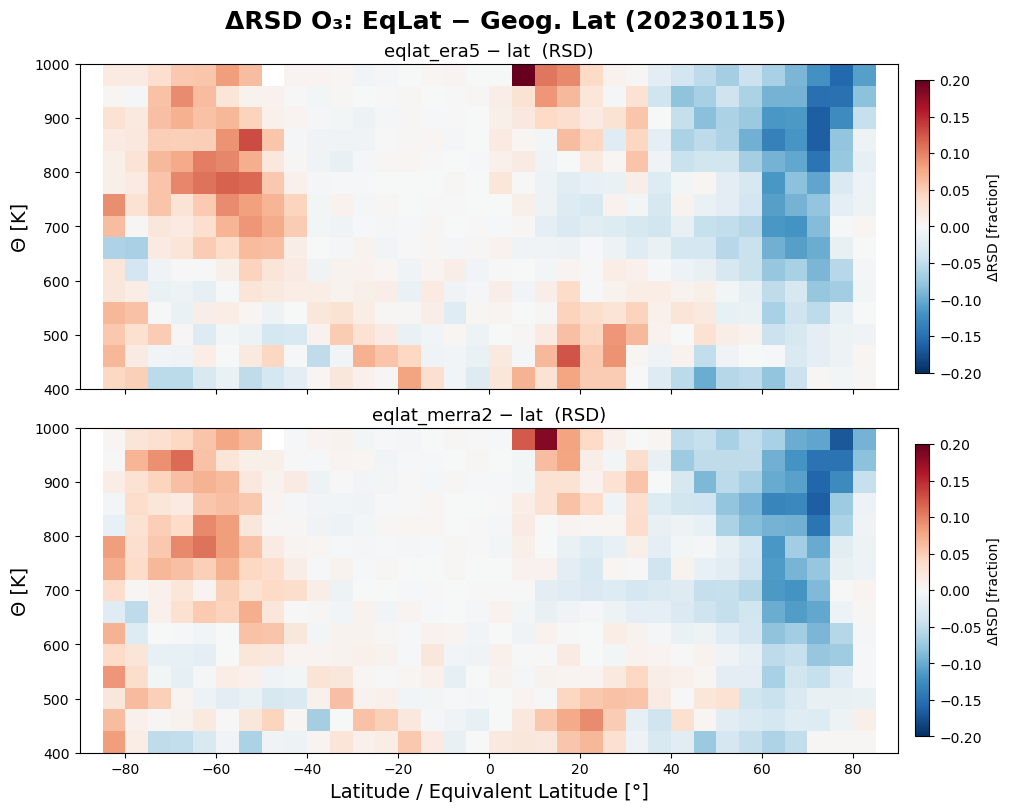

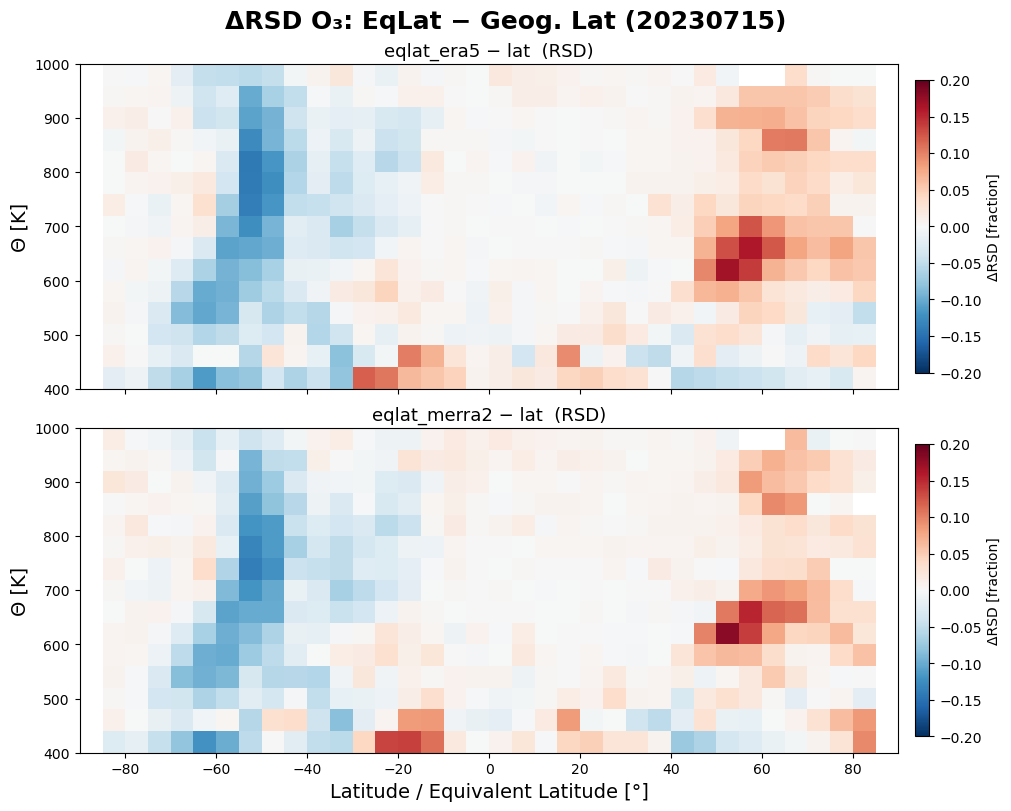

In [175]:
plot_std_difference(mls_w_eqlat_20230115, 'O3',
                    geo_coord='lat',
                    diff_lims=(-0.2, 0.2),
                    eqlat_coords=['eqlat_era5', 'eqlat_merra2'],
                    plot_type='rsd',
                    title="ΔRSD O₃: EqLat − Geog. Lat (20230115)")

plot_std_difference(mls_w_eqlat_20230715, 'O3',
                    geo_coord='lat',
                    diff_lims=(-0.2, 0.2),
                    eqlat_coords=['eqlat_era5', 'eqlat_merra2'],
                    plot_type='rsd',
                    title="ΔRSD O₃: EqLat − Geog. Lat (20230715)")


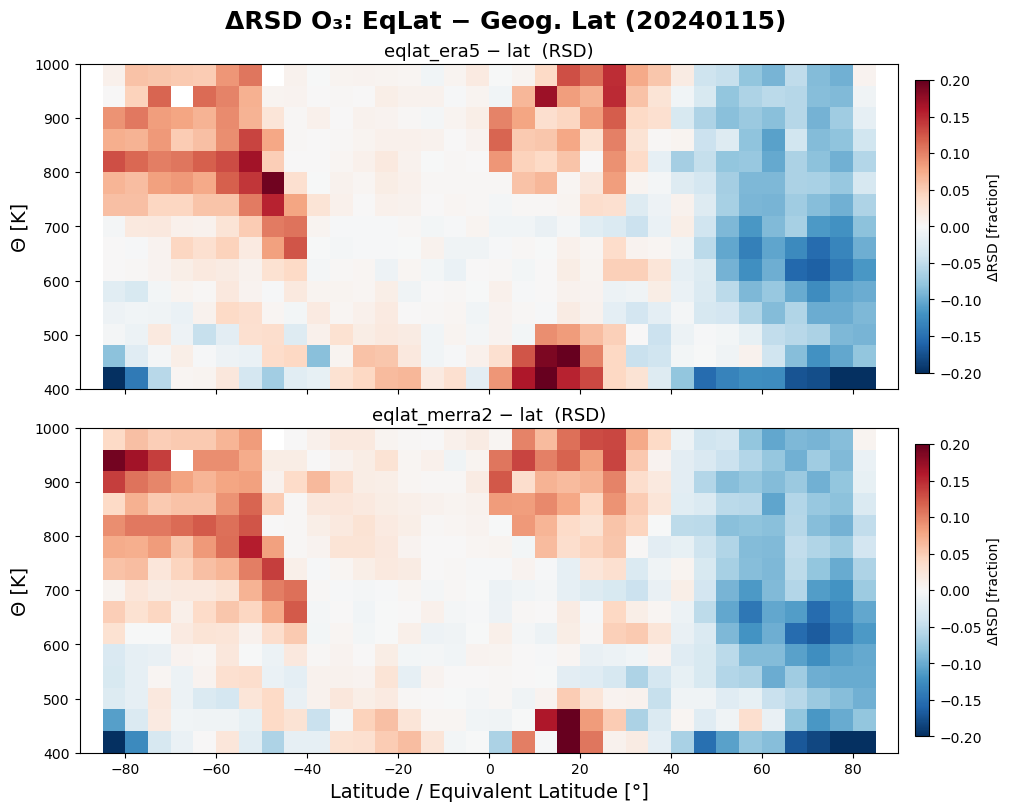

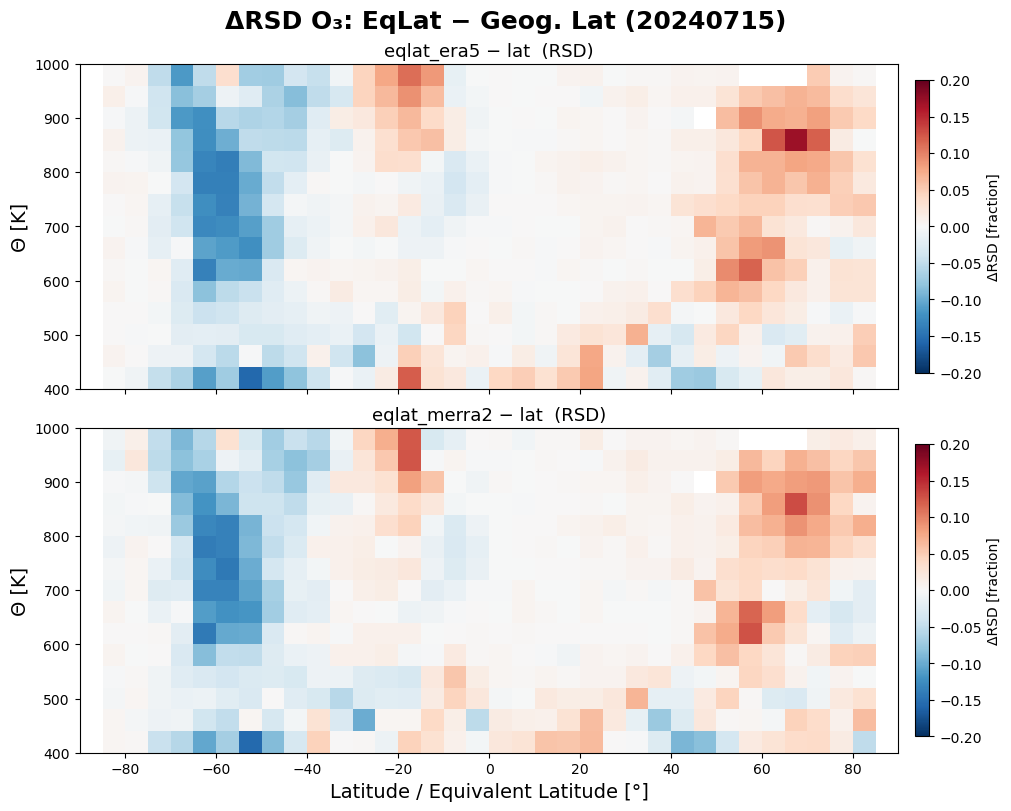

In [176]:
plot_std_difference(mls_w_eqlat_20240115, 'O3',
                    geo_coord='lat',
                    diff_lims=(-0.2, 0.2),
                    eqlat_coords=['eqlat_era5', 'eqlat_merra2'],
                    plot_type='rsd',
                    title="ΔRSD O₃: EqLat − Geog. Lat (20240115)")

plot_std_difference(mls_w_eqlat_20240715, 'O3',
                    geo_coord='lat',
                    diff_lims=(-0.2, 0.2),
                    eqlat_coords=['eqlat_era5', 'eqlat_merra2'],
                    plot_type='rsd',
                    title="ΔRSD O₃: EqLat − Geog. Lat (20240715)")

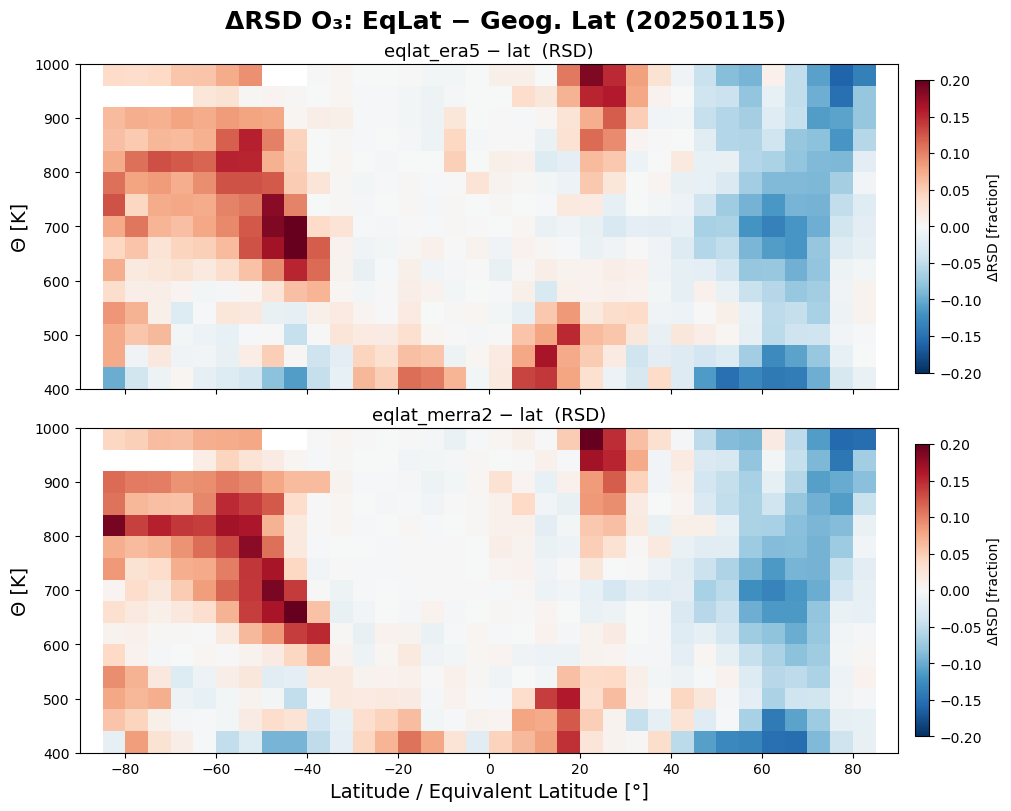

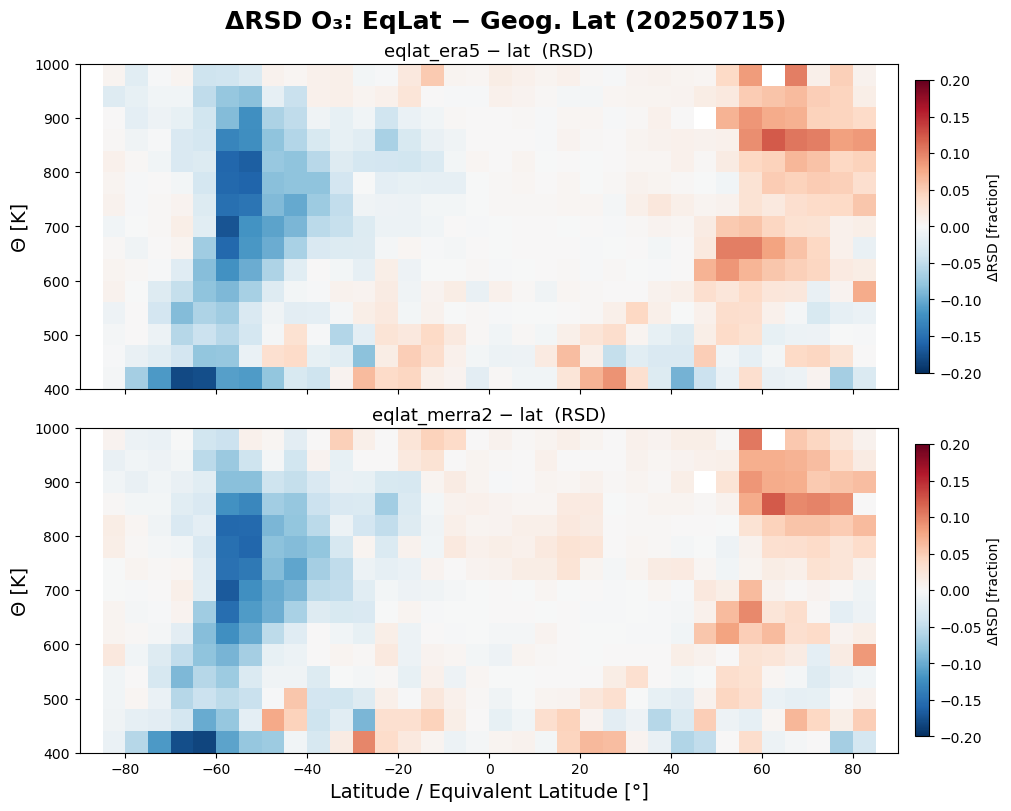

In [174]:
# plot_type='std'  → absolute Differenz der Standardabweichung
# plot_type='rsd'  → Differenz der relativen Standardabweichung (Variationskoeffizient)
plot_std_difference(mls_w_eqlat_20250115, 'O3',
                    geo_coord='lat',
                    diff_lims=(-0.2, 0.2),
                    eqlat_coords=['eqlat_era5', 'eqlat_merra2'],
                    plot_type='rsd',
                    title="ΔRSD O₃: EqLat − Geog. Lat (20250115)")

plot_std_difference(mls_w_eqlat_20250715, 'O3',
                    geo_coord='lat',
                    diff_lims=(-0.2, 0.2),
                    eqlat_coords=['eqlat_era5', 'eqlat_merra2'],
                    plot_type='rsd',
                    title="ΔRSD O₃: EqLat − Geog. Lat (20250715)")



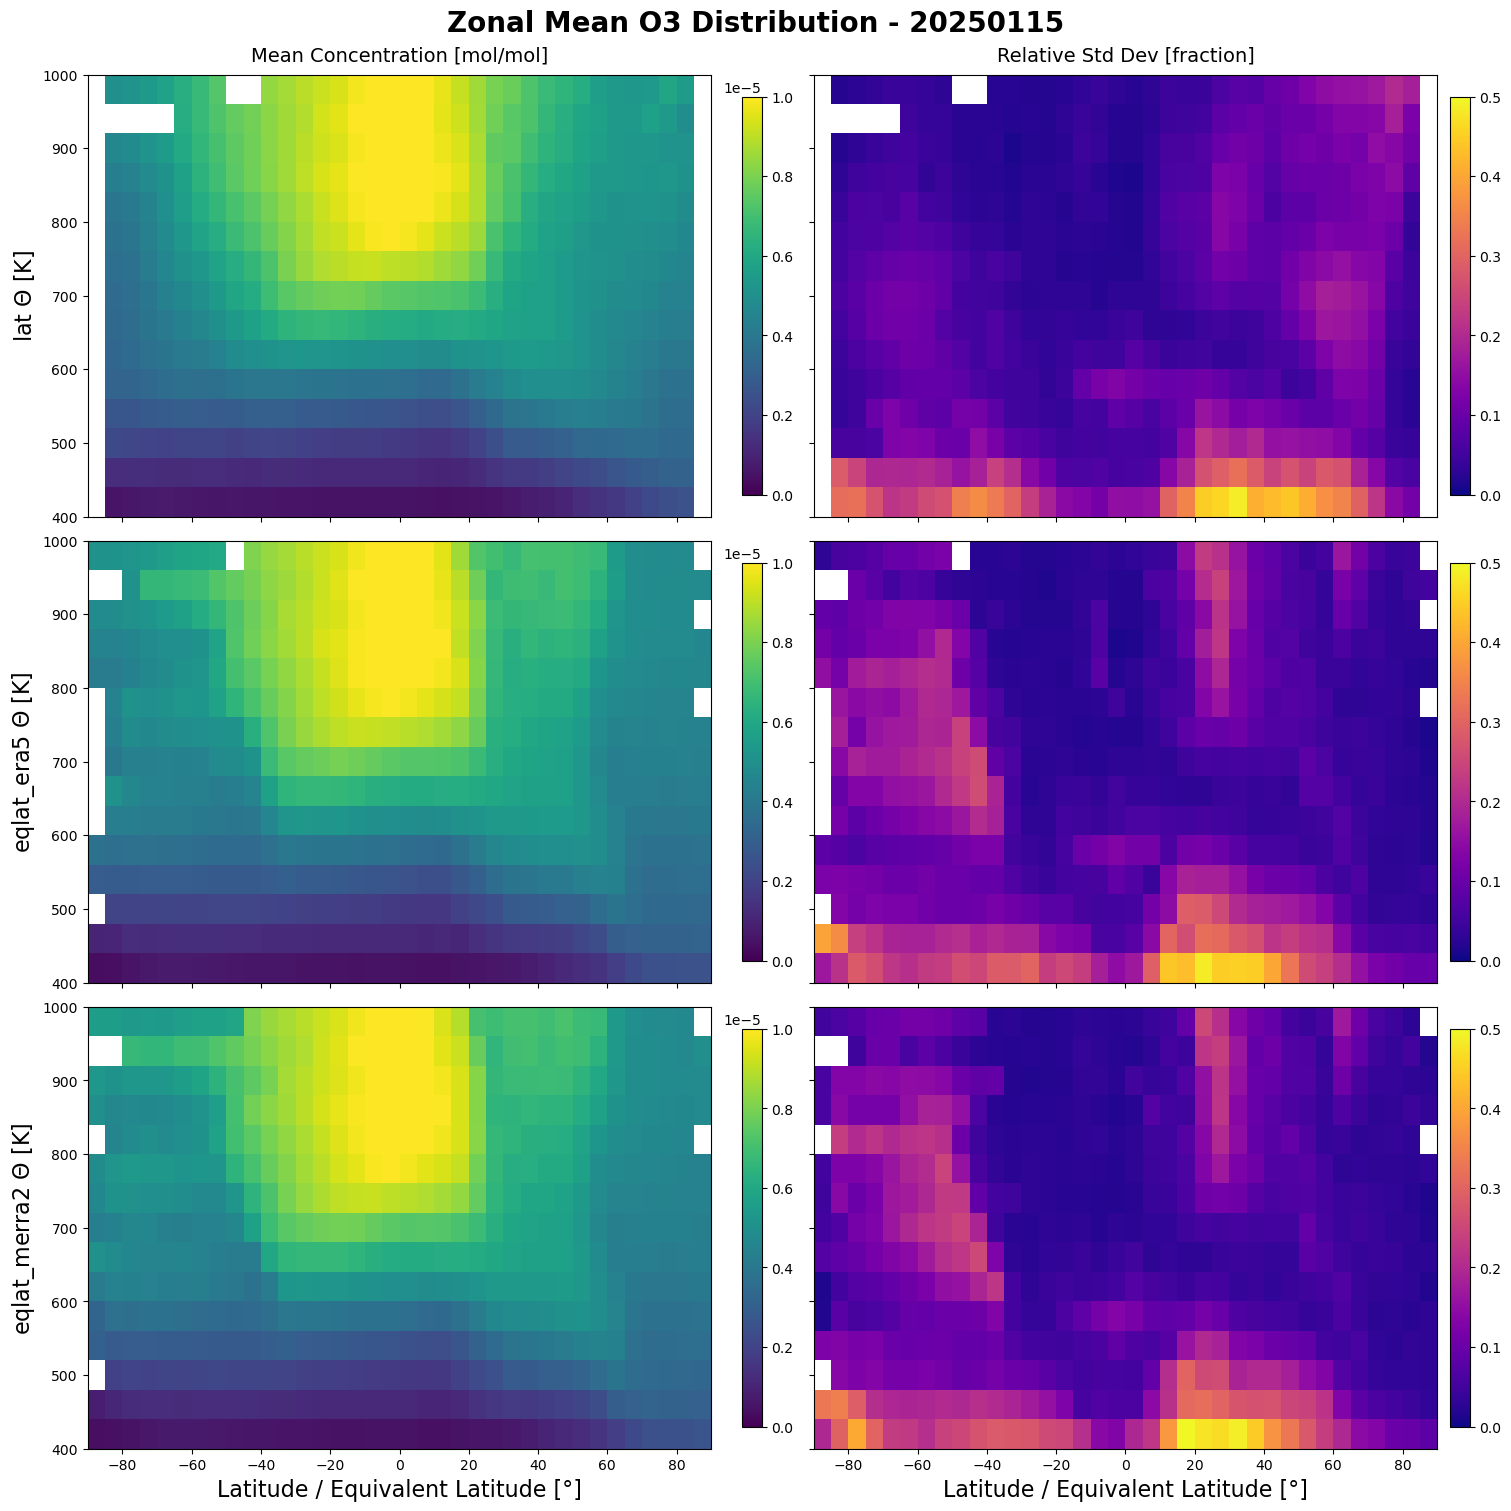

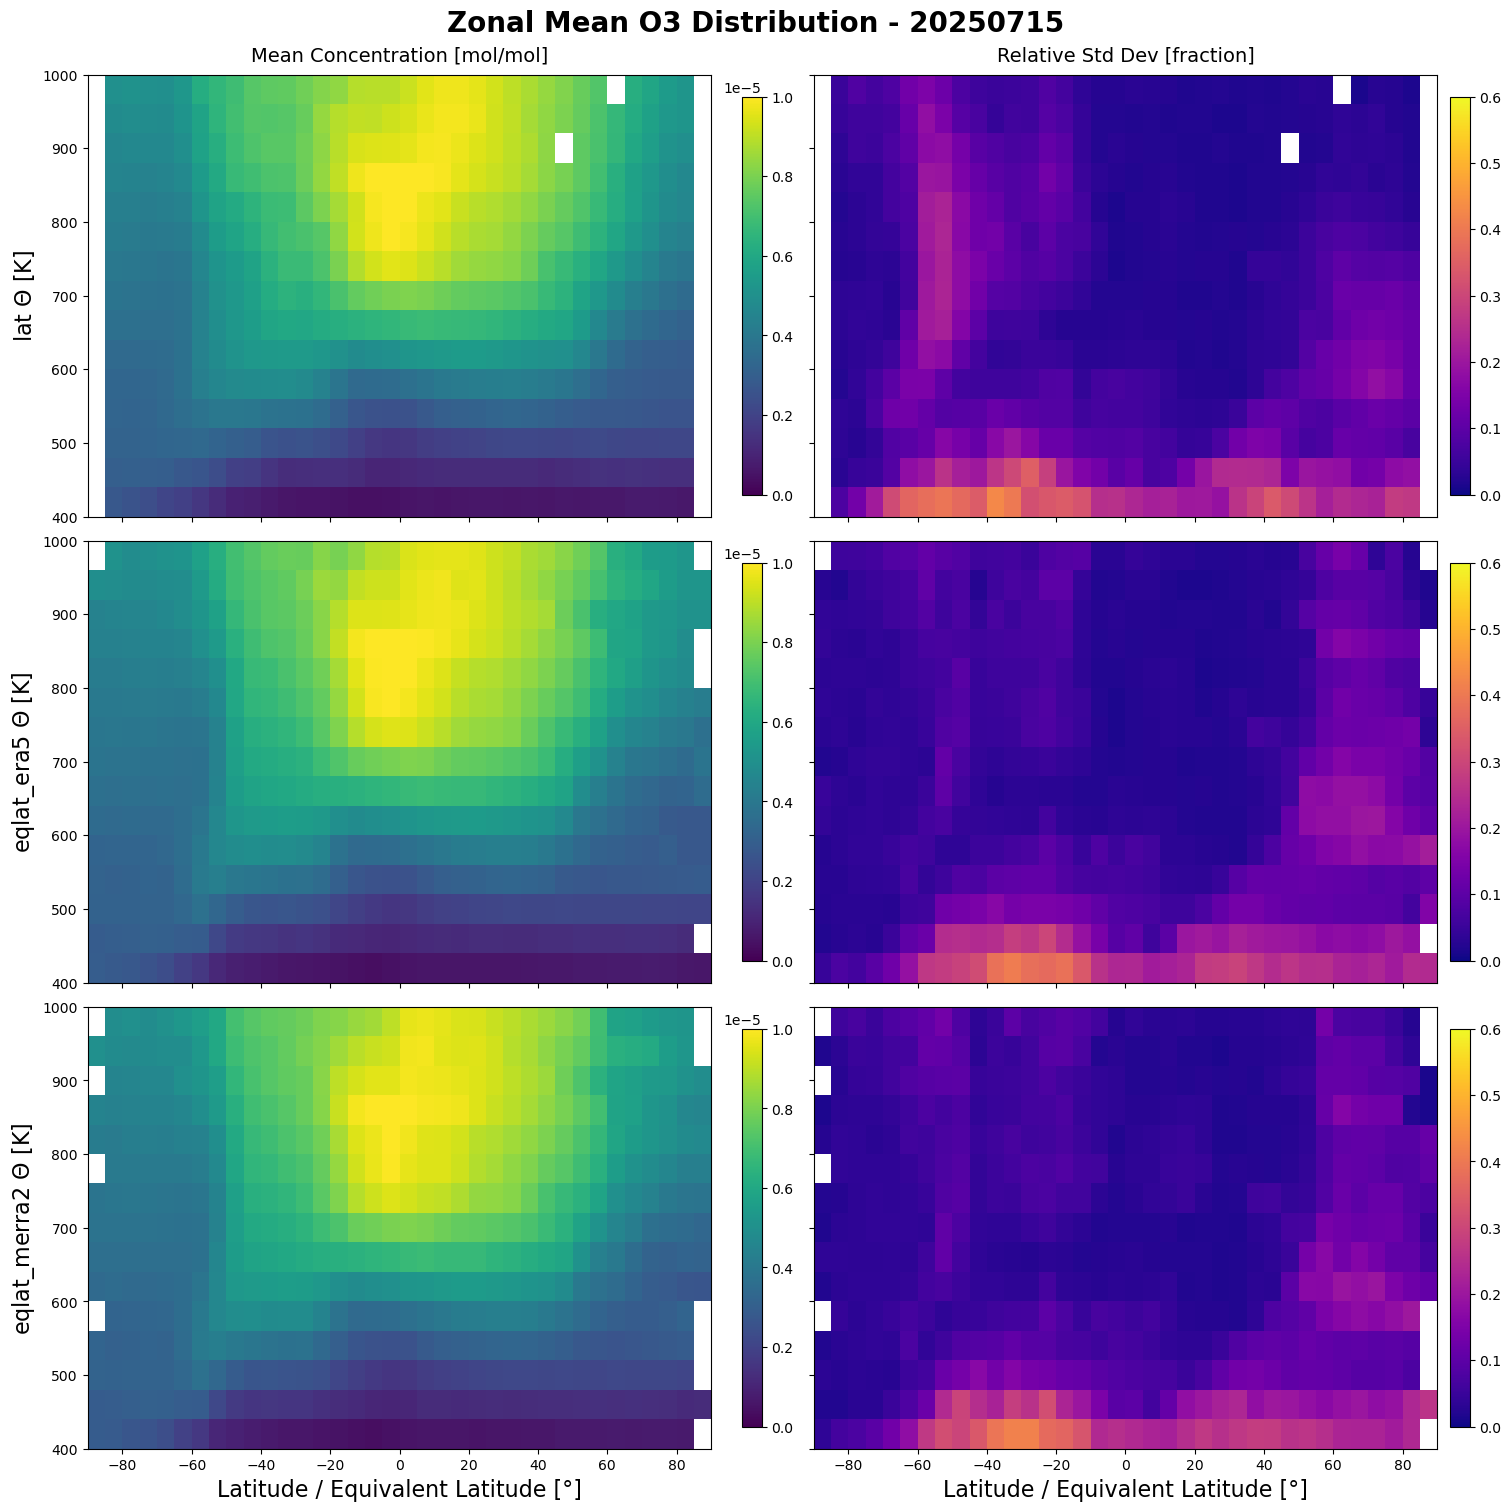

In [177]:
# the coordinates for the plot (have to be in the mls_eqlat product)
coords_list = ['lat', 'eqlat_era5', 'eqlat_merra2']
# Adjust these numbers based on your actual O3 units (e.g., ppm)
plot_all_coordinates_grid(mls_w_eqlat_20250115, 'O3', coords_list, 
                          mean_lims=(0, 1e-5), 
                          #std_lims=(0, 2e-6),
                          std_lims=(0, 0.5),
                          plot_type='rsd',
                          title="Zonal Mean O3 Distribution - 20250115")

plot_all_coordinates_grid(mls_w_eqlat_20250715, 'O3', coords_list, 
                          mean_lims=(0, 1e-5), 
                          #std_lims=(0, 2e-6),
                          std_lims=(0, 0.6),
                          plot_type='rsd',
                          title="Zonal Mean O3 Distribution - 20250715")

## Dynamik vs. Photochemie: Diagnose des subtropischen EqLat-RSD-Effekts

Diese Diagnose untersucht, ob die erhoehte RSD von EqLat gegenueber geographischer Breite bei ~20N, Theta=800-1000K dynamisch (schwacher/flacher PV-Gradient am subtropischen Rand, verstaerkt durch Wellenbrechen im NH-Winter) oder photochemisch (SZA-/Temperatur-gesteuertes lokales Gleichgewicht) verursacht wird.

Vier Panels:
- **A/B**: PV-Karte (Lon/Lat) auf einem festen Theta-Level fuer zwei Termine/Jahreszeiten -> zeigt filamentartige Strukturen (Wellenbrechen) vs. glatte, zonal symmetrische Felder.
- **C**: Zonal gemittelter meridionaler PV-Gradient (dPV/dlat) vs. Breite fuer mehrere Theta-Level -> zeigt die Zone mit (nahezu) verschwindendem Gradienten.
- **D**: RSD-Balkenvergleich (geographische Breite vs. EqLat ERA5/MERRA2) in einer Lat/Theta-Box -> quantifiziert den Effekt und ob er in beiden Jahreszeiten/Koordinaten gleich gross ist (photochemische Signatur) oder jahreszeitenspezifisch und durch EqLat verstaerkt wird (dynamische Signatur).


In [197]:
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D


def plot_dynamics_vs_chemistry_diagnostic(
        era5_ds_1, era5_ds_2,
        mls_ds_1, mls_ds_2,
        labels=("Season 1", "Season 2"),
        var_name="O3",
        geo_coord="lat",
        eqlat_coords=("eqlat_era5", "eqlat_merra2"),
        theta_pv_map=850,
        theta_gradient_levels=(800, 900, 1000),
        lat_map_range=(-20, 40),
        weak_gradient_lat_range=(12, 20),
        sharp_gradient_lat_range=(25, 30),
        box_lat_range=(18, 28),
        box_theta_range=(750, 950),
        theta_bins=np.linspace(400, 1000, 16),
        lat_bins=np.linspace(-90, 90, 37),
        time_dim="valid_time",
        time_index=0,
        pv_vlims=(0, 2e2),
        title=""):
    """
    Diagnostic figure distinguishing a dynamical from a photochemical cause for
    elevated relative standard deviation (RSD) of a tracer in equivalent-latitude
    (EqLat) bins versus geographic-latitude bins.

    The figure has four panels:

    A/B : Isentropic PV maps (longitude vs. latitude) at `theta_pv_map`, one per
          input `era5_ds`, for a single time step (`time_index` along `time_dim`).
          Filamentary / wave-broken PV structure indicates synoptic disturbance
          (Rossby wave breaking) rather than a smooth, photochemically-controlled
          field, which would instead look zonally homogeneous.

    C   : Zonal-mean meridional PV gradient (dPV/dlat) versus latitude for each
          theta level in `theta_gradient_levels`, for both input dates/seasons.
          A near-zero gradient in `weak_gradient_lat_range` indicates an
          ill-conditioned region for the area-PV inversion that defines
          equivalent latitude (small PV noise maps to large EqLat excursions).
          `sharp_gradient_lat_range` is shaded for reference (e.g. the displaced
          subtropical jet edge).

    D   : Bar chart of mean RSD (std/mean) of `var_name`, computed via
          `create_2d_climatology`, in the box defined by `box_lat_range` and
          `box_theta_range`, for `geo_coord` and each of `eqlat_coords`, for both
          `mls_ds_1` and `mls_ds_2`. A RSD increase confined to one season *and*
          amplified specifically in EqLat coordinates supports a dynamical cause;
          a comparable increase present in both seasons and already visible in
          `geo_coord` alone would instead point to a photochemical/SZA-driven
          cause, since photochemical equilibrium is organised by true latitude
          (solar zenith angle), not by PV.

    Parameters
    ----------
    era5_ds_1, era5_ds_2 : xarray.Dataset
        Gridded reanalysis datasets containing 'pv_isentropic' with dims
        (time_dim, theta, latitude, longitude), as produced by
        `batch.process_pressure_netcdf` / `process_fields`.
    mls_ds_1, mls_ds_2 : xarray.Dataset
        MLS observation datasets with `var_name`, 'theta', `geo_coord` and
        `eqlat_coords`, as produced by `eqlat_at_mls`.
    labels : tuple of str, optional
        Labels for the two input dates/seasons (e.g. ('Jan', 'Jul')).
    var_name : str, optional
        Tracer variable to analyse in panel D. Default 'O3'.
    geo_coord : str, optional
        Geographic latitude coordinate name in the MLS datasets. Default 'lat'.
    eqlat_coords : sequence of str, optional
        Equivalent-latitude coordinate names to compare. Default
        ('eqlat_era5', 'eqlat_merra2').
    theta_pv_map : float, optional
        Potential temperature level [K] for the PV maps (panels A/B). Default 850.
    theta_gradient_levels : sequence of float, optional
        Potential temperature levels [K] for the PV-gradient curves (panel C).
        Default (800, 900, 1000).
    lat_map_range : tuple of float, optional
        (lat_max, lat_min) latitude range plotted in panels A/B. Default (-20, 60).
    weak_gradient_lat_range : tuple of float, optional
        Latitude band highlighted in panels A-C as the candidate weak/flat PV
        gradient zone. Default (12, 20).
    sharp_gradient_lat_range : tuple of float, optional
        Latitude band highlighted in panels A-C as the candidate sharp-gradient
        (jet) zone. Default (25, 30).
    box_lat_range, box_theta_range : tuple of float, optional
        Latitude / theta box used to compute the panel D RSD summary statistics.
        Default (18, 28) and (750, 950).
    theta_bins, lat_bins : array_like, optional
        Bin edges passed through to `create_2d_climatology`.
    time_dim : str, optional
        Name of the time dimension in `era5_ds_1`/`era5_ds_2` (e.g. 'valid_time'
        for ERA5-derived files, 'time' for MERRA2-derived files). Default
        'valid_time'.
    time_index : int, optional
        Index along `time_dim` used for the PV maps and gradient curves (panels
        A-C). Default 0.
    pv_vlims : tuple of float, optional
        Colour limits (x1e-6 K m^2 kg^-1 s^-1) for the PV maps. Default (0, 2e2).
    title : str, optional
        Figure super-title.

    Returns
    -------
    fig : matplotlib.figure.Figure
        The assembled 2x2 diagnostic figure.
    """
    fig = plt.figure(figsize=(14, 10))
    gs = GridSpec(2, 2, height_ratios=[1, 1], hspace=0.4, wspace=0.35, figure=fig)

    # ---- Panels A/B: PV maps ----
    era5_list = [era5_ds_1, era5_ds_2]
    pv_maps = []
    for ds in era5_list:
        da_full = ds["pv_isentropic"].isel({time_dim: time_index}).sel(
            theta=theta_pv_map, method="nearest"
        )
        # 'latitude' may be ascending or descending depending on the source grid
        lat_descending = ds["latitude"].values[0] > ds["latitude"].values[-1]
        lat_slice = (slice(lat_map_range[1], lat_map_range[0]) if lat_descending
                     else slice(lat_map_range[0], lat_map_range[1]))
        pv_maps.append(da_full.sel(latitude=lat_slice).load())

    for i, (da, label) in enumerate(zip(pv_maps, labels)):
        ax = fig.add_subplot(gs[0, i])
        pcm = ax.pcolormesh(da.longitude, da.latitude, da.values * 1e6,
                             cmap="viridis", vmin=pv_vlims[0], vmax=pv_vlims[1],
                             shading="auto")
        #ax.axhspan(*weak_gradient_lat_range, color="red", alpha=0.15, lw=0)
        #ax.axhspan(*sharp_gradient_lat_range, color="cyan", alpha=0.15, lw=0)
        ax.set_title(f"{'AB'[i]}) PV @ {theta_pv_map:.0f}K, {label}",
                     fontsize=11, fontweight="bold")
        ax.set_xlabel("Longitude [°E]")
        ax.set_ylabel("Latitude [°N]")
        cb = plt.colorbar(pcm, ax=ax, pad=0.02)
        cb.set_label("PV [1e-6 K m² kg⁻¹ s⁻¹]", fontsize=9)

    # ---- Panel C: zonal-mean PV gradient ----
    ax = fig.add_subplot(gs[1, 0])
    cmap_cycle = plt.cm.tab10(np.linspace(0, 1, len(theta_gradient_levels)))
    for ds, ls, label in zip(era5_list, ["-", "--"], labels):
        pv = ds["pv_isentropic"].isel({time_dim: time_index}).sel(
            theta=list(theta_gradient_levels), method="nearest")
        pv_zm = pv.mean(dim="longitude")
        lat = ds["latitude"].values
        sel = (lat >= 0) & (lat <= 40)
        lat_s = lat[sel]
        order = np.argsort(lat_s)
        lat_sorted = lat_s[order]
        for th, c in zip(pv_zm.theta.values, cmap_cycle):
            vals = pv_zm.sel(theta=th).values[sel][order]
            grad = np.gradient(vals, lat_sorted)
            ax.plot(lat_sorted, grad * 1e6, ls, color=c, alpha=0.9)
    #ax.axhspan(-0.5, 0.5, color="red", alpha=0.08)
    ax.axvspan(*weak_gradient_lat_range, color="red", alpha=0.08)
    ax.axhline(0, color="gray", lw=0.7)
    ax.set_xlabel("Latitude [°N]")
    ax.set_ylabel(r"$d\mathrm{PV}/d\mathrm{lat}$  [1e-6 K m² kg⁻¹ s⁻¹ / °]")
    ax.set_title("C) Meridional PV-Gradient (zonal mean)\n"
                 f"θ={','.join(f'{t:.0f}' for t in theta_gradient_levels)}K — "
                 f"solid {labels[0]}, dashed {labels[1]}",
                 fontsize=11, fontweight="bold")
    handles = [Line2D([0], [0], color=c, lw=2) for c in cmap_cycle] + \
              [Line2D([0], [0], color="k", lw=2, ls="-"),
               Line2D([0], [0], color="k", lw=2, ls="--")]
    handle_labels = [f"{t:.0f}K" for t in theta_gradient_levels] + list(labels)
    ax.legend(handles, handle_labels, fontsize=8, ncol=2, loc="best")

    # ---- Panel D: RSD bar chart ----
    results = {}
    for label, ds in zip(labels, [mls_ds_1, mls_ds_2]):
        for coord in (geo_coord,) + tuple(eqlat_coords):
            m, s, _, x_e, y_e = create_2d_climatology(
                ds, var_name, coord, theta_bins=theta_bins, lat_bins=lat_bins
            )
            rsd = np.divide(s, m, out=np.full_like(s, np.nan), where=m != 0)
            lat_idx = [i for i in range(len(lat_bins) - 1)
                       if box_lat_range[0] <= lat_bins[i] <= box_lat_range[1]]
            theta_idx = [i for i in range(len(theta_bins) - 1)
                         if box_theta_range[0] <= theta_bins[i] <= box_theta_range[1]]
            results[(label, coord)] = np.nanmean(rsd[np.ix_(lat_idx, theta_idx)])

    ax = fig.add_subplot(gs[1, 1])
    coords = (geo_coord,) + tuple(eqlat_coords)
    x = np.arange(len(coords))
    width = 0.35
    vals_1 = [results[(labels[0], c)] for c in coords]
    vals_2 = [results[(labels[1], c)] for c in coords]
    ax.bar(x - width / 2, vals_1, width, label=labels[0], color="firebrick")
    ax.bar(x + width / 2, vals_2, width, label=labels[1], color="steelblue")
    ax.set_xticks(x)
    ax.set_xticklabels(coords, fontsize=9)
    ax.set_ylabel(f"mean RSD {var_name} [fraction]")
    ax.set_title(f"D) RSD-Comparison, Box {box_lat_range[0]:.0f}–{box_lat_range[1]:.0f}°N, "
                 f"θ={box_theta_range[0]:.0f}–{box_theta_range[1]:.0f}K",
                 fontsize=11, fontweight="bold")
    ax.legend(fontsize=9)
    for i, (v1, v2) in enumerate(zip(vals_1, vals_2)):
        ax.text(i - width / 2, v1 + 0.005, f"{v1:.3f}", ha="center", fontsize=8)
        ax.text(i + width / 2, v2 + 0.005, f"{v2:.3f}", ha="center", fontsize=8)

    fig.suptitle(title, fontsize=14, fontweight="bold", y=0.995)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

    return fig


/var/folders/_9/rlrj6gw54653j66jwjb_srb00000gn/T/ipykernel_50957/4075660290.py:204: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.97])


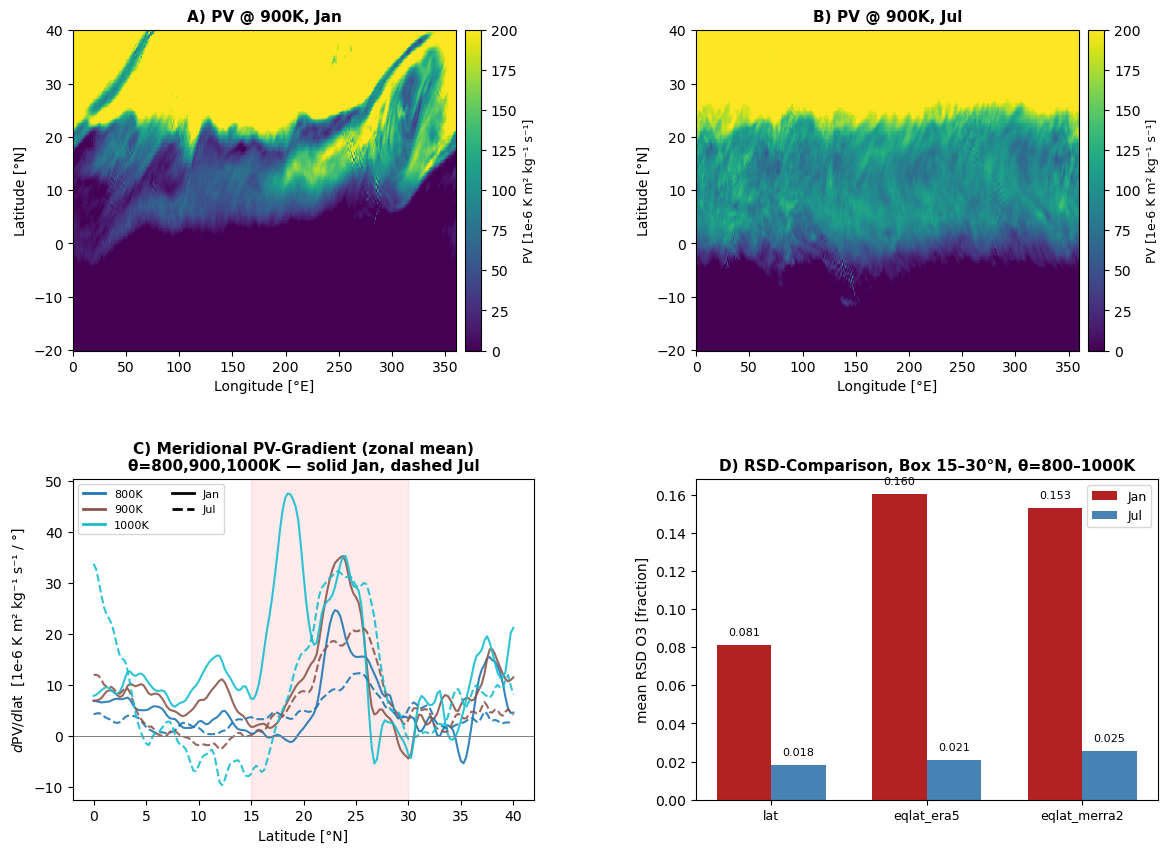

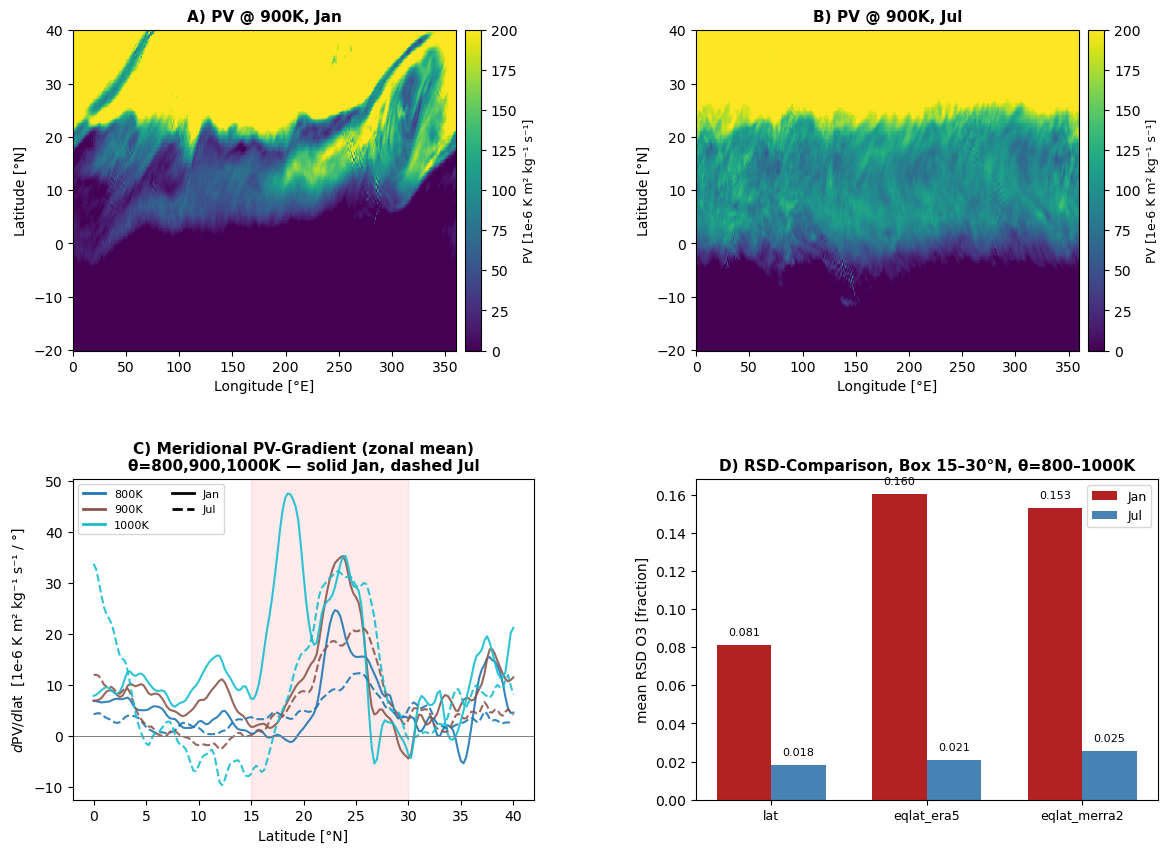

In [204]:
# Beispielaufruf mit den bereits geladenen 2025-Datensaetzen.
# Fuer ERA5 ist die Zeitdimension 'valid_time', fuer eine MERRA2-basierte
# PV-Quelle waere stattdessen time_dim='time' zu verwenden.
plot_dynamics_vs_chemistry_diagnostic(
    era5_20250115, era5_20250715,
    mls_w_eqlat_20250115, mls_w_eqlat_20250715,
    labels=("Jan", "Jul"),
    var_name="O3",
    theta_pv_map=900,
    theta_gradient_levels=(800, 900, 1000),
    weak_gradient_lat_range=(15, 30),
    sharp_gradient_lat_range=(25, 30),
    box_lat_range=(15, 30),
    box_theta_range=(800, 1000),
    time_index=0,
    time_dim="valid_time",
)
